# **Image Based Animal Type Classification for Cow and Buffaloes**

In [15]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
import os

base_path = "/content/drive/MyDrive/Colab Notebooks/datasets"

print("Cow Images:", len(os.listdir(base_path+"/Cow")))
print("Buffalo Images:", len(os.listdir(base_path+"/Buffalo")))

Cow Images: 515
Buffalo Images: 515


In [17]:
import os, random, shutil

base_path = "/content/drive/MyDrive/Colab Notebooks/datasets"

os.makedirs(base_path + "/train/cow",     exist_ok=True)
os.makedirs(base_path + "/train/buffalo", exist_ok=True)
os.makedirs(base_path + "/test/cow",      exist_ok=True)
os.makedirs(base_path + "/test/buffalo",  exist_ok=True)

def split_data(source, train, test, split_size=0.8):
    files = os.listdir(source)
    random.shuffle(files)
    split_point = int(len(files) * split_size)
    for file in files[:split_point]:
        shutil.copy(os.path.join(source, file), train)
    for file in files[split_point:]:
        shutil.copy(os.path.join(source, file), test)

split_data(base_path + "/Cow",     base_path + "/train/cow",     base_path + "/test/cow")
split_data(base_path + "/Buffalo", base_path + "/train/buffalo", base_path + "/test/buffalo")

print("Dataset Split Completed ✅")

Dataset Split Completed ✅


In [18]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import numpy as np
import matplotlib.pyplot as plt

In [19]:
dataset_path = "/content/drive/MyDrive/Colab Notebooks/datasets"

# preprocess_input scales pixels to [-1, 1] as MobileNetV2 expects
train_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input,
    rotation_range         = 20,
    zoom_range             = 0.2,
    shear_range            = 0.2,
    horizontal_flip        = True
)

test_datagen = ImageDataGenerator(
    preprocessing_function = preprocess_input
)

In [20]:
train_data = train_datagen.flow_from_directory(
    dataset_path + "/train",
    target_size = (224, 224),   # MobileNetV2 native size
    batch_size  = 32,
    class_mode  = 'binary',
    shuffle     = True
)

test_data = test_datagen.flow_from_directory(
    dataset_path + "/test",
    target_size = (224, 224),
    batch_size  = 32,
    class_mode  = 'binary'
)

print(train_data.class_indices)

Found 988 images belonging to 2 classes.
Found 370 images belonging to 2 classes.
{'buffalo': 0, 'cow': 1}


In [21]:
# 1. Load MobileNetV2 pretrained on ImageNet
base_model = MobileNetV2(
    weights     = 'imagenet',    # already trained on 1.28M images
    include_top = False,         # remove the 1000-class head
    input_shape = (224, 224, 3)
)

# 2. Freeze the entire backbone — weights won't change during training
base_model.trainable = False

# 3. Add our small classification head on top
x = base_model.output
x = GlobalAveragePooling2D()(x)    # converts feature maps → 1280-d vector
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
output = Dense(1, activation='sigmoid')(x)

model = Model(inputs=base_model.input, outputs=output)

# 4. Compile
model.compile(
    optimizer = 'adam',
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

# 5. Show how many params are frozen vs trainable
trainable     = sum(p.numpy().size for p in model.trainable_weights)
non_trainable = sum(p.numpy().size for p in model.non_trainable_weights)
print(f"Trainable params    (our head) : {trainable:>10,}  ← only these update")
print(f"Non-trainable params (backbone): {non_trainable:>10,}  ← frozen")
print(f"Total params                   : {trainable + non_trainable:>10,}")

Trainable params    (our head) :    164,097  ← only these update
Non-trainable params (backbone):  2,257,984  ← frozen
Total params                   :  2,422,081


In [22]:
callbacks = [
    EarlyStopping(monitor='val_accuracy', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.3,
                      patience=3, verbose=1)
]

history = model.fit(
    train_data,
    epochs          = 15,
    validation_data = test_data,
    callbacks       = callbacks
)

Epoch 1/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 88s 3s/step - accuracy: 0.9119 - loss: 0.1934 - val_accuracy: 0.9865 - val_loss: 0.0387 - learning_rate: 0.0010
Epoch 2/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 70s 2s/step - accuracy: 0.9757 - loss: 0.0625 - val_accuracy: 0.9946 - val_loss: 0.0293 - learning_rate: 0.0010
Epoch 3/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 72s 2s/step - accuracy: 0.9909 - loss: 0.0293 - val_accuracy: 1.0000 - val_loss: 0.0142 - learning_rate: 0.0010
Epoch 4/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 74s 2s/step - accuracy: 0.9899 - loss: 0.0322 - val_accuracy: 0.9973 - val_loss: 0.0219 - learning_rate: 0.0010
Epoch 5/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9919 - loss: 0.0240 - val_accuracy: 0.9892 - val_loss: 0.0341 - learning_rate: 0.0010
Epoch 6/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 71s 2s/step - accuracy: 0.9879 - loss: 0.0326 - val_accuracy: 0.9973 - val_loss: 0.0113 - learning_rate: 0.0010
Epoch 7/15
31/31 ━━━━━━━━━━━━━━━━━━━━ 68s 2s/step - accuracy: 0.9939 - loss: 0.0183 - val_accuracy: 

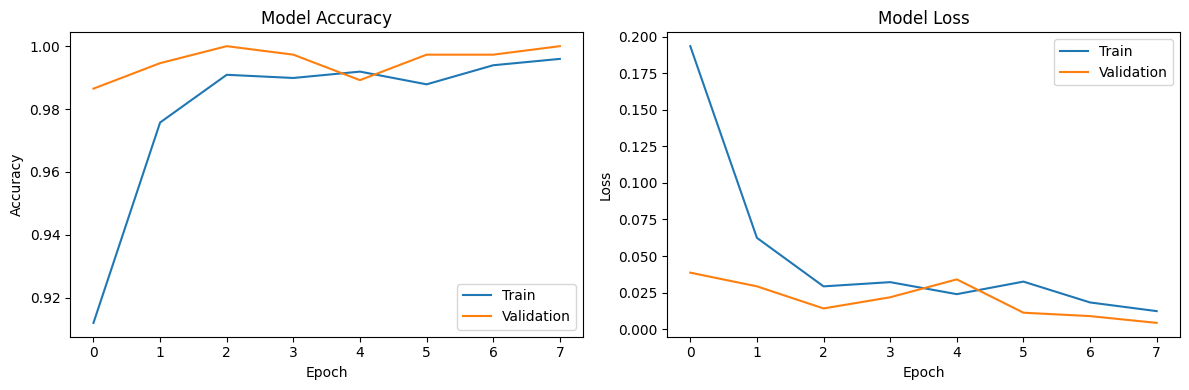

In [23]:
plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'],     label='Train')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'],     label='Train')
plt.plot(history.history['val_loss'], label='Validation')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [24]:
loss, acc = model.evaluate(test_data, verbose=1)
print(f"\nTest Accuracy : {acc * 100:.2f}%")
print(f"Test Loss     : {loss:.4f}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 16s 1s/step - accuracy: 1.0000 - loss: 0.0142

Test Accuracy : 100.00%
Test Loss     : 0.0142


Found layer: global_average_pooling2d_1
12/12 ━━━━━━━━━━━━━━━━━━━━ 20s 2s/step
Feature matrix shape: (370, 1280)


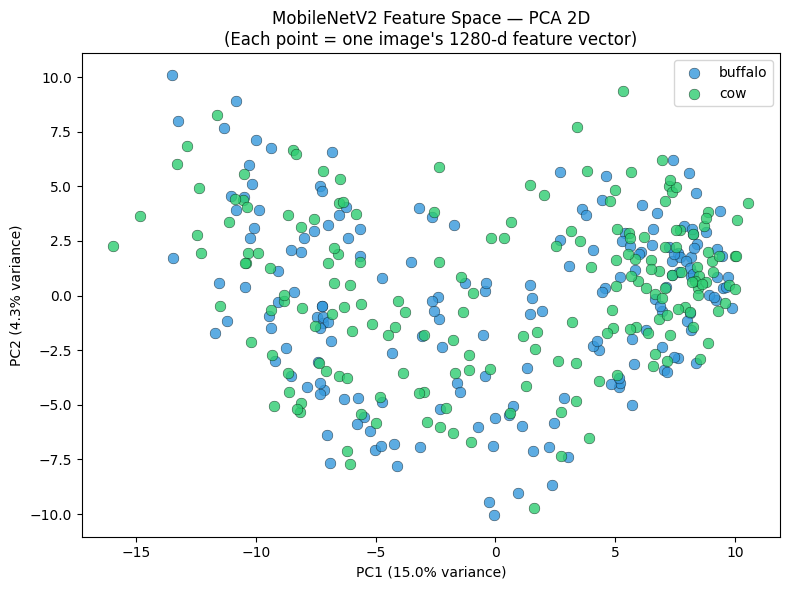

In [28]:
from sklearn.decomposition import PCA

# Auto-detect the GlobalAveragePooling2D layer name
gap_layer = None
for layer in model.layers:
    if 'global_average_pooling' in layer.name.lower():
        gap_layer = layer.name
        break

print(f"Found layer: {gap_layer}")

# Build feature extractor using the detected layer name
feature_extractor = Model(
    inputs  = model.input,
    outputs = model.get_layer(gap_layer).output
)

# Extract features for all test images
test_data.reset()
features = feature_extractor.predict(test_data, verbose=1)
labels   = test_data.classes

print(f"Feature matrix shape: {features.shape}")  # (N, 1280)

# Reduce 1280-d → 2D using PCA so we can plot it
pca = PCA(n_components=2)
pts = pca.fit_transform(features)

# Plot
colors = {'cow': '#2ecc71', 'buffalo': '#3498db'}
plt.figure(figsize=(8, 6))

for cls, idx in test_data.class_indices.items():
    mask = labels == idx
    plt.scatter(pts[mask, 0], pts[mask, 1],
                label=cls, color=colors[cls],
                s=60, alpha=0.8, edgecolors='k', linewidths=0.3)

plt.title("MobileNetV2 Feature Space — PCA 2D\n"
          "(Each point = one image's 1280-d feature vector)")
plt.xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
plt.ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
plt.legend()
plt.tight_layout()
plt.show()